# Shelving Filters

Shelving filters boost or cut all frequencies on one side of a transition frequency (`cutoff`) by a fixed `gain_db`, leaving the other side flat. They are the canonical bass and treble controls in any audio EQ chain.

Both filters use the Audio EQ Cookbook biquad design — the gain is applied as a smooth S-curve transition rather than a brick wall, giving a natural-sounding shelf slope.

| Function | Description |
| --- | --- |
| `lowshelf` | Second-order low-shelf biquad. Boosts or cuts all frequencies **below** `cutoff` by `gain_db`; flat response above. |
| `highshelf` | Second-order high-shelf biquad. Boosts or cuts all frequencies **above** `cutoff` by `gain_db`; flat response below. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.filters import highshelf, lowshelf
from python.generators import generate_impulse

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Frequency responses (top row) and impulse responses (bottom row) for both shelving filter types.

**Top row — magnitude in dB, log-frequency x-axis:**
- **Low-shelf:** −6, 0, +6 dB gain at cutoff = 1000 Hz — boost lifts the low-frequency shelf above 0 dB; cut depresses it; 0 dB (grey) is flat passthrough
- **High-shelf:** −6, 0, +6 dB gain at cutoff = 1000 Hz — same gain values but applied to the high-frequency shelf; transition region is a smooth S-curve centred on cutoff

**Bottom row — impulse response, first 30 ms:**
- Boost impulse responses have a positive DC offset (low-shelf boost → energy at DC) and ring briefly at the shelf transition
- Cut impulse responses show a negative initial lobe followed by a small positive correction
- The shelving transition bandwidth is related to Q; at Q = 1/√2 it matches the original analogue Baxandall prototype

Shelving filters are routinely used in pairs (one low-shelf + one high-shelf) to form a two-band tone control, and in the feedback path of reverb algorithms.


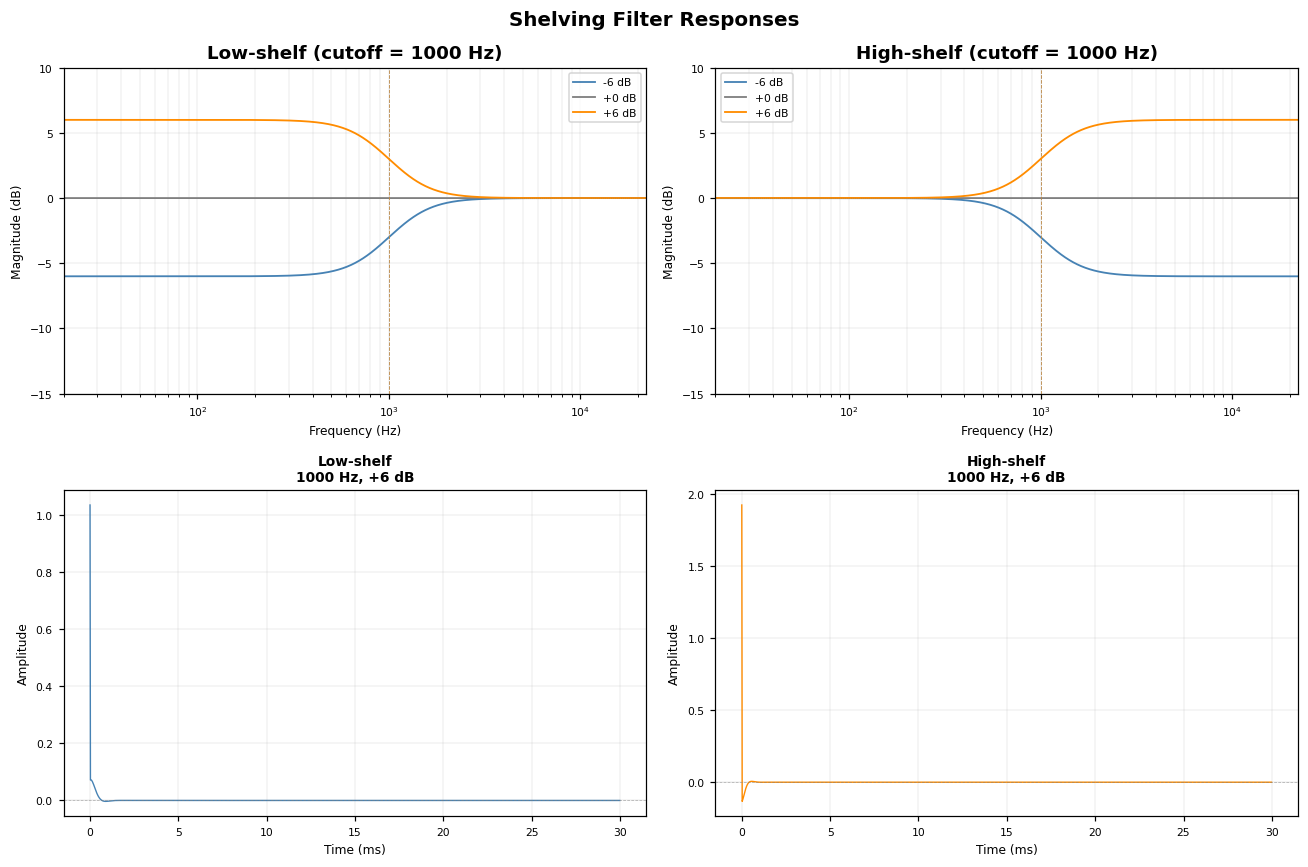

In [2]:
FS = 44100
DURATION = 1.0
WINDOW_MS = 30

SHELF_GAINS = [-6.0, 0.0, 6.0]
SHELF_COLORS = ["steelblue", "gray", "darkorange"]


def _impulse() -> np.ndarray:
    _, imp = generate_impulse(fs=FS, duration=DURATION)
    return imp


def _freq_response(h: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    spectrum = np.abs(np.fft.rfft(h))
    freqs = np.fft.rfftfreq(len(h), d=1.0 / FS)
    db = 20.0 * np.log10(spectrum + 1e-12)
    return freqs, db


def _plot_freq(ax, freqs, db, label, color, cutoff=None):
    mask = freqs > 0
    ax.semilogx(freqs[mask], db[mask], label=label, color=color, linewidth=1.2)
    if cutoff is not None:
        ax.axvline(cutoff, color=color, linewidth=0.6, linestyle="--", alpha=0.5)


def _plot_ir(ax, h, label, color):
    n = int(WINDOW_MS * FS / 1000)
    t_ms = np.arange(n) / FS * 1000
    ax.plot(t_ms, h[:n], color=color, linewidth=0.9, label=label)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

imp = _impulse()

# ── Row 0: frequency responses ────────────────────────────────────────────────

ax = axes[0, 0]
for gain, color in zip(SHELF_GAINS, SHELF_COLORS):
    h = lowshelf(imp, cutoff=1000.0, fs=FS, gain_db=gain)
    _plot_freq(ax, *_freq_response(h), label=f"{gain:+.0f} dB", color=color, cutoff=1000.0)
ax.set_title("Low-shelf (cutoff = 1000 Hz)", fontweight="bold")
ax.set_ylim(-15, 10)

ax = axes[0, 1]
for gain, color in zip(SHELF_GAINS, SHELF_COLORS):
    h = highshelf(imp, cutoff=1000.0, fs=FS, gain_db=gain)
    _plot_freq(ax, *_freq_response(h), label=f"{gain:+.0f} dB", color=color, cutoff=1000.0)
ax.set_title("High-shelf (cutoff = 1000 Hz)", fontweight="bold")
ax.set_ylim(-15, 10)

for ax in axes[0]:
    ax.set_xlabel("Frequency (Hz)", fontsize=8)
    ax.set_ylabel("Magnitude (dB)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", linewidth=0.3, alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle=":", alpha=0.7)
    ax.legend(fontsize=7)
    ax.set_xlim(20, FS / 2)

# ── Row 1: impulse responses ──────────────────────────────────────────────────

IR_SPECS = [
    ("Low-shelf\n1000 Hz, +6 dB",  lowshelf,  dict(cutoff=1000.0, gain_db=6.0)),
    ("High-shelf\n1000 Hz, +6 dB", highshelf, dict(cutoff=1000.0, gain_db=6.0)),
]

IR_COLORS = ["steelblue", "darkorange"]

for (title, fn, kwargs), ax, color in zip(IR_SPECS, axes[1], IR_COLORS):
    h = fn(imp, fs=FS, **kwargs)
    _plot_ir(ax, h, label=title.split("\n")[0], color=color)
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.set_xlabel("Time (ms)", fontsize=8)
    ax.set_ylabel("Amplitude", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)

fig.suptitle("Shelving Filter Responses", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()